In [101]:
import numpy as np
import pandas as pd
import array
import matplotlib.pyplot as plt
import seaborn as sns
import math
from plotnine import *
from array import *
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_classification
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
import os, sys

## Parte a) - Análisis exploratorio del conjunto de datos

In [102]:
#Cargar el archivo
from google.colab import files
uploaded = files.upload()
datos = pd.read_csv("Problema 3.csv")

Saving Problema 3.csv to Problema 3 (2).csv


In [103]:
#Mostrar las primeras 10 observaciones
datos.head(10)

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low
5,40.0,2.0,10.25,6.78,0.0,19.0,27.0,4.0,15.15,0.78,51.06,Medium
6,26.0,NaN,6.53,7.60,6.0,4.0,11.0,9.0,9.38,0.54,39.09,Medium
7,38.0,0.0,10.69,5.25,5.0,12.0,2.0,2.0,14.58,0.10,77.68,High
8,42.0,18.0,11.47,4.79,4.0,11.0,25.0,1.0,14.54,1.53,73.56,High
9,30.0,17.0,13.16,5.39,3.0,0.0,3.0,3.0,14.44,0.58,46.78,Medium


In [104]:
#Mostrar las últimas 10 observaciones
datos.tail(10)

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
6990,28.0,19.0,10.31,8.57,1.0,12.0,21.0,8.0,13.54,0.75,53.31,Medium
6991,21.0,1.0,5.38,6.80,5.0,10.0,10.0,3.0,8.81,NaN,42.12,Medium
6992,44.0,7.0,4.39,6.99,2.0,13.0,16.0,NaN,6.22,1.19,31.07,Low
6993,37.0,12.0,5.37,5.73,5.0,15.0,8.0,6.0,7.56,1.41,50.89,Medium
6994,28.0,19.0,6.86,5.86,2.0,5.0,25.0,2.0,8.29,0.04,32.26,Low
6995,25.0,14.0,6.53,7.43,5.0,1.0,7.0,5.0,7.55,1.67,20.10,Low
6996,30.0,19.0,10.15,5.60,3.0,4.0,9.0,0.0,12.11,0.96,41.71,Medium
6997,44.0,8.0,8.56,6.80,5.0,18.0,3.0,4.0,11.62,1.04,80.15,High
6998,25.0,2.0,4.39,5.40,6.0,6.0,4.0,5.0,8.24,0.82,41.44,Medium
6999,25.0,2.0,4.35,4.83,1.0,16.0,23.0,4.0,8.52,1.98,39.18,Medium


In [105]:
#Información general del dataset
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   object 
dtypes: float64(11), object(1)
memory usage: 656.4+ KB


In [106]:
#Estadísticos descriptivos
datos.describe()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
count,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000
mean,32.129446,9.581050,9.000277,6.485638,3.540671,9.482653,14.458455,4.545044,11.974773,1.007611,53.652825
std,7.230254,5.760972,2.863944,1.445008,2.283445,5.751664,8.669846,2.856766,3.091204,0.576708,23.446656
min,20.000000,0.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,5.210000,0.000000,0.000000
25%,26.000000,5.000000,6.560000,5.220000,2.000000,5.000000,7.000000,2.000000,9.460000,0.510000,36.587500
50%,32.000000,10.000000,8.990000,6.460000,4.000000,9.000000,14.000000,5.000000,12.020000,1.020000,53.795000
75%,38.000000,15.000000,11.422500,7.740000,6.000000,14.000000,22.000000,7.000000,14.422500,1.510000,70.800000
max,44.000000,19.000000,14.000000,9.000000,7.000000,19.000000,29.000000,9.000000,18.930000,2.000000,100.000000


In [107]:
#Verificar valores nulos
print("Valores nulos por variable:")
print(datos.isnull().sum())

Valores nulos por variable:
age                 140
experience_years    140
daily_work_hours    140
sleep_hours         140
caffeine_intake     140
bugs_per_day        140
commits_per_day     140
meetings_per_day    140
screen_time         140
exercise_hours      140
stress_level        140
burnout_level       140
dtype: int64


In [108]:
#Distribución de la variable respuesta
print("Distribución de burnout_level:")
print(datos["burnout_level"].value_counts())

Distribución de burnout_level:
burnout_level
Medium    3485
High      1782
Low       1593
Name: count, dtype: int64


In [109]:
#Eliminar filas con valores nulos
datos = datos.dropna()
print("Registros después de eliminar nulos: %s" %str(datos.shape[0]))

Registros después de eliminar nulos: 5490


In [110]:
#Codificar la variable respuesta (High=0, Low=1, Medium=2)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
datos["burnout_encoded"] = le.fit_transform(datos["burnout_level"])
print("Clases codificadas: %s" %str(le.classes_))

predictoras = datos.drop(["burnout_level", "burnout_encoded"], axis=1)
respuesta = datos["burnout_encoded"]

Clases codificadas: ['High' 'Low' 'Medium']


<Figure size 640x480 with 0 Axes>

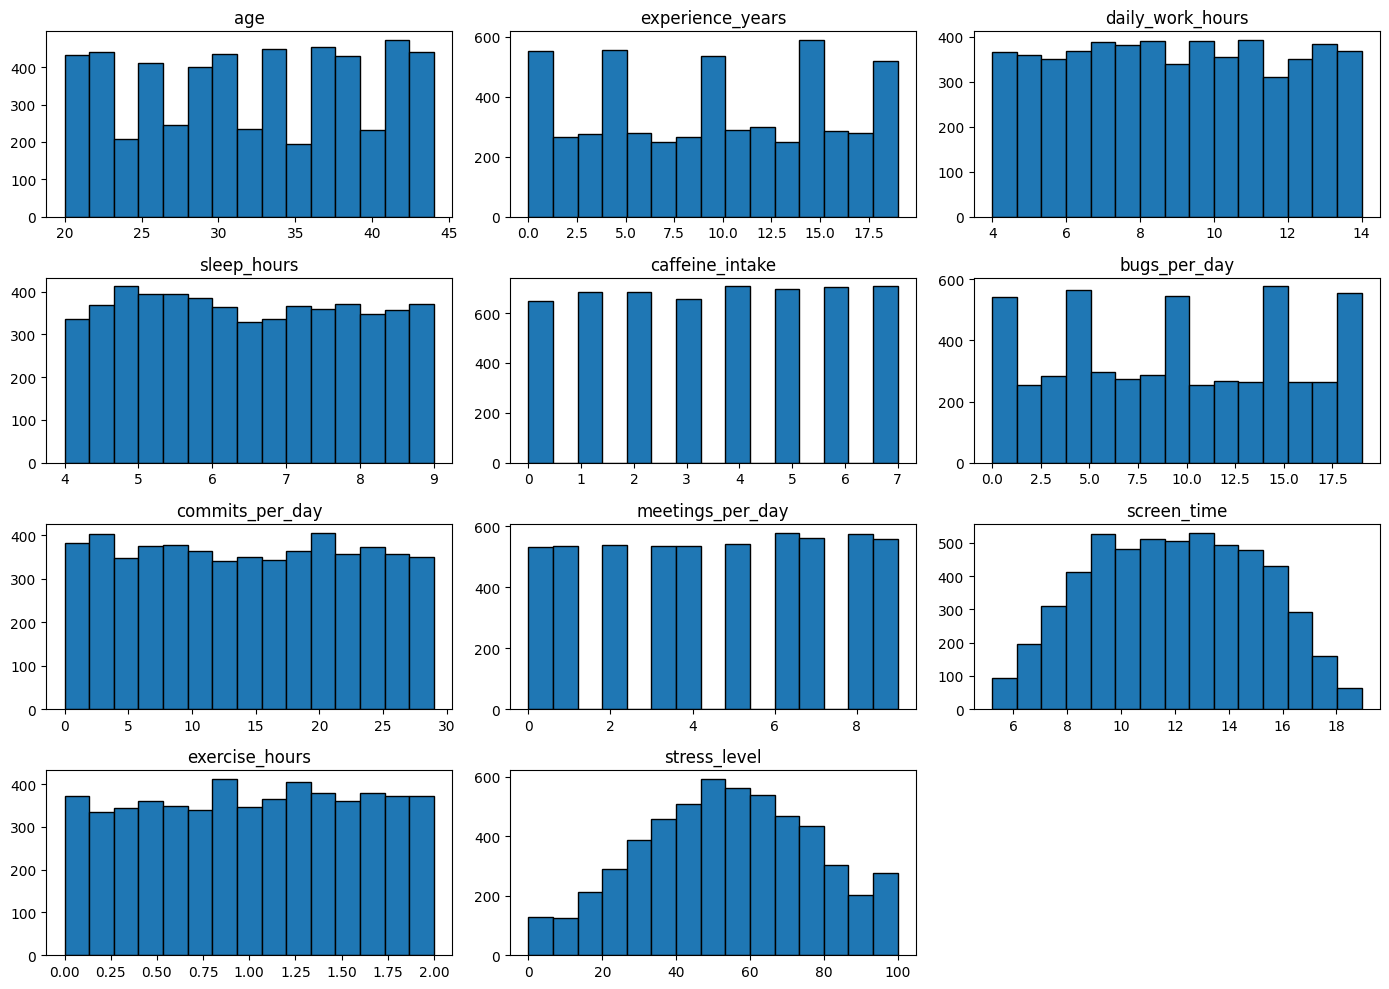

In [111]:
#Histogramas de las variables predictoras
plt.figure()
predictoras.hist(figsize=(14, 10), bins=15, edgecolor="black", grid=False)
plt.tight_layout()
plt.show()

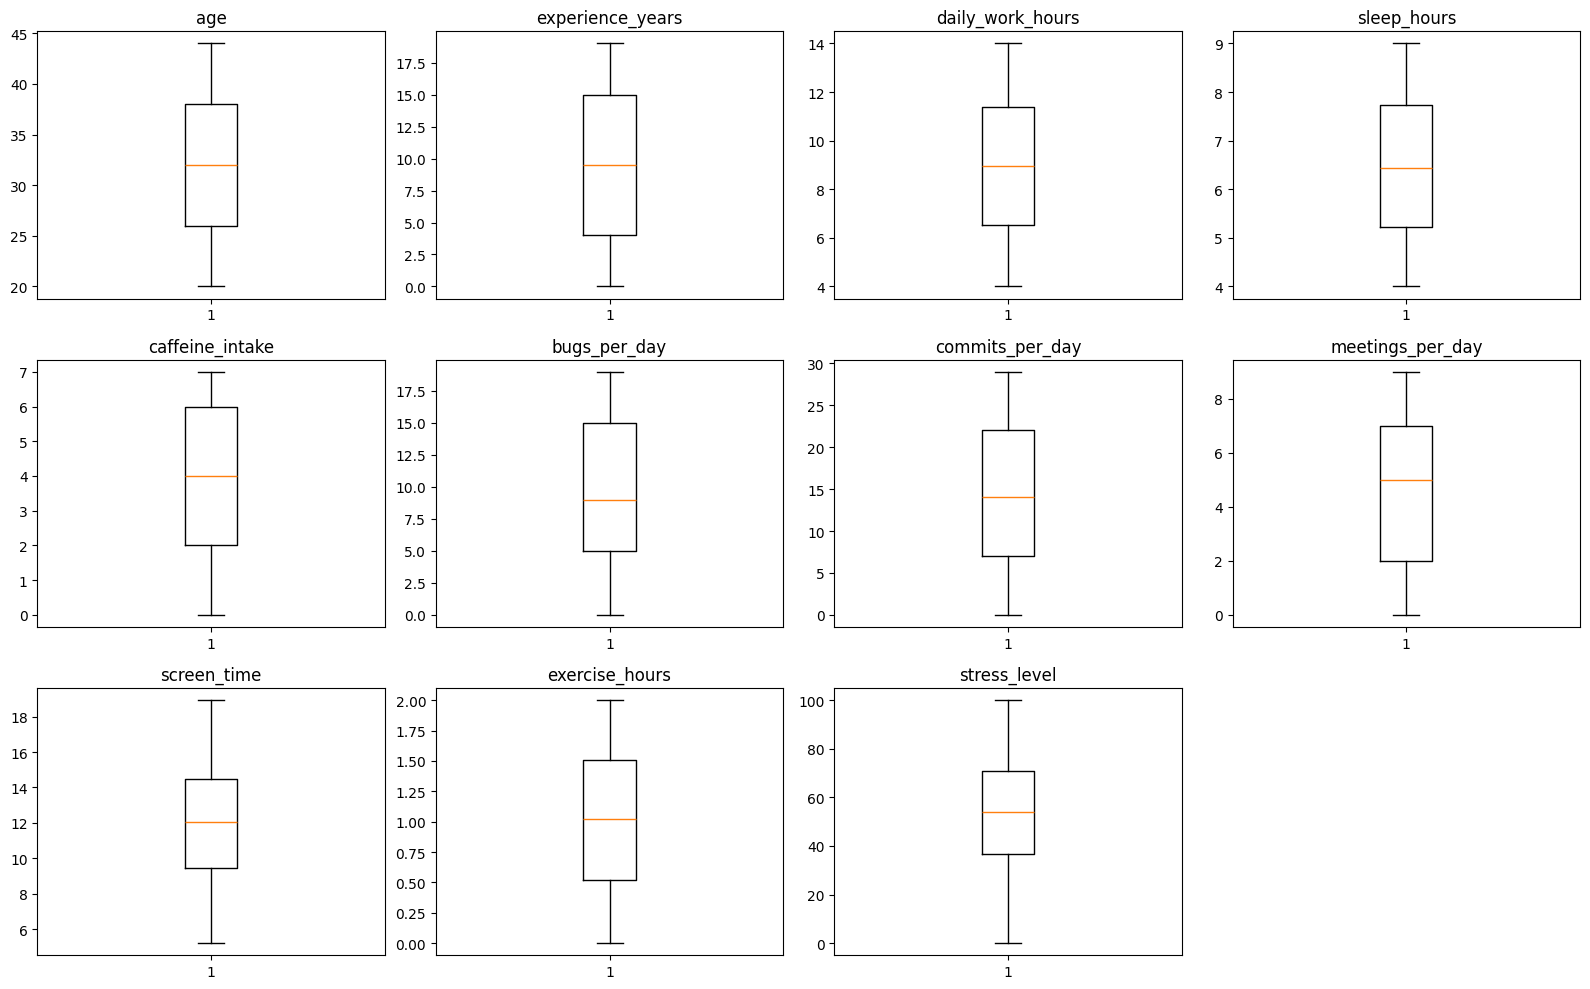

In [112]:
#Diagramas de caja y bigote de las variables predictoras
plt.figure(figsize=(16, 10))
for i, var in enumerate(predictoras.columns):
    plt.subplot(3, 4, i+1)
    plt.boxplot(predictoras[var])
    plt.title(var)
plt.tight_layout()
plt.show()

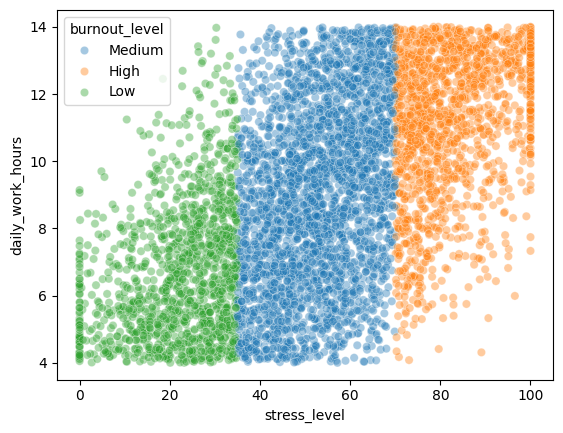

In [113]:
#Diagrama de dispersión clasificado por burnout_level (stress_level vs daily_work_hours)
plt.figure()
sns.scatterplot(data=datos, x="stress_level", y="daily_work_hours",
                hue="burnout_level", alpha=0.4)
plt.show()

## Parte b) - División del conjunto de datos

In [114]:
#Dividir el conjunto de datos en entrenamiento (70%) y validación (30%)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(predictoras, respuesta,
                                                     test_size=0.30, random_state=20230196)

print("Tamaño del conjunto de entrenamiento: %s" %str(X_train.shape))
print("Tamaño del conjunto de validación: %s" %str(X_test.shape))

Tamaño del conjunto de entrenamiento: (3843, 11)
Tamaño del conjunto de validación: (1647, 11)


## Parte c) - Regresión logística

In [115]:
#Estandarizar las variables predictoras para la regresión logística
from sklearn.preprocessing import StandardScaler

escalar = StandardScaler()
escalar.fit(X_train)

X_train_sc = pd.DataFrame(escalar.transform(X_train), columns=predictoras.columns)
X_test_sc = pd.DataFrame(escalar.transform(X_test), columns=predictoras.columns)

In [116]:
#Ajustar el modelo de regresión logística con todas las variables predictoras
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000, random_state=20230196)
lr.fit(X_train_sc, y_train)

LogisticRegression(max_iter=2000, random_state=20230196)

In [117]:
#Obtener el accuracy_score
from sklearn.metrics import accuracy_score

y_pred_lr = lr.predict(X_test_sc)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("El accuracy score que se tiene es %s" %accuracy_lr)

El accuracy score que se tiene es 0.98421372191864


In [118]:
#Mostrar el intercepto
print("El intercepto para este modelo es %s" %lr.intercept_)

El intercepto para este modelo es [-2.7419511  -3.49095742  6.23290852]


In [119]:
#Mostrar los coeficientes asociados
coefs = pd.DataFrame(lr.coef_.T,
                     index=predictoras.columns,
                     columns=le.classes_)
coefs

,High,Low,Medium
age,-0.037061,0.043086,-0.006025
experience_years,-0.023447,-0.000914,0.024361
daily_work_hours,0.160088,-0.258406,0.098318
sleep_hours,-0.160182,0.235240,-0.075058
caffeine_intake,0.196492,-0.232657,0.036165
bugs_per_day,0.444694,-0.494409,0.049715
commits_per_day,-0.096430,0.127733,-0.031303
meetings_per_day,0.230951,-0.350408,0.119457
screen_time,0.224257,-0.240194,0.015937
exercise_hours,-0.129987,0.168804,-0.038817


In [120]:
#Añadir el intercepto
X2 = sm.add_constant(X_train_sc.reset_index(drop=True))
y2 = y_train.reset_index(drop=True)

#Ajustar el modelo
est = sm.MNLogit(y2, X2)
est2 = est.fit()

#Ver el ajuste
print(est2.summary())

Optimization terminated successfully.
         Current function value: nan
         Iterations 13
                          MNLogit Regression Results                          
Dep. Variable:        burnout_encoded   No. Observations:                 3843
Model:                        MNLogit   Df Residuals:                     3819
Method:                           MLE   Df Model:                           22
Date:                Wed, 10 Jun 2026   Pseudo R-squ.:                     nan
Time:                        01:59:14   Log-Likelihood:                    nan
converged:                       True   LL-Null:                       -3988.9
Covariance Type:            nonrobust   LLR p-value:                       nan
burnout_encoded=1       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                    nan        nan        nan        nan         nan         nan
age         

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3027: RuntimeWarning: overflow encountered in exp
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3028: RuntimeWarning: invalid value encountered in divide


Text(50.722222222222214, 0.5, 'Real')

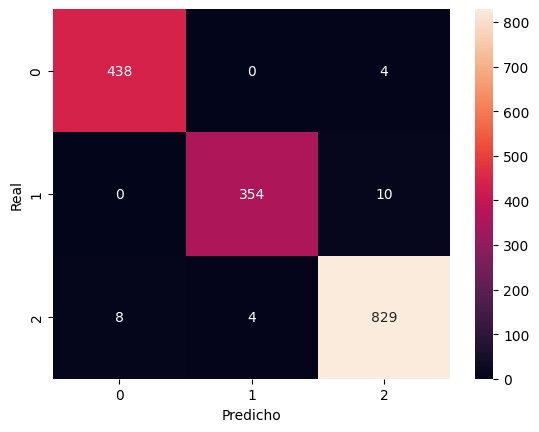

In [121]:
#Obtener la matriz de confusión
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [122]:
#Obtener la precisión, recall y F1
from sklearn.metrics import precision_score, recall_score, f1_score

precision_lr = precision_score(y_test, y_pred_lr, average="macro")
recall_lr = recall_score(y_test, y_pred_lr, average="macro")
f1_lr = f1_score(y_test, y_pred_lr, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"],
                          "Valores": [precision_lr, recall_lr, f1_lr]})
metricas

,Métricas,Valores
0,Precisión,0.984761
1,Recall,0.983070
2,F1,0.983885


## Parte d) - KNN con dos variables predictoras

In [123]:
#Seleccionar las dos variables con mayor correlación absoluta con la variable respuesta
correlaciones = predictoras.corrwith(respuesta).abs().sort_values(ascending=False)
print("Correlaciones absolutas con burnout_level:")
print(correlaciones)

Correlaciones absolutas con burnout_level:
stress_level        0.414885
daily_work_hours    0.248330
bugs_per_day        0.227995
screen_time         0.223303
meetings_per_day    0.130554
sleep_hours         0.080229
caffeine_intake     0.077793
exercise_hours      0.046093
commits_per_day     0.007946
experience_years    0.007301
age                 0.006166
dtype: float64


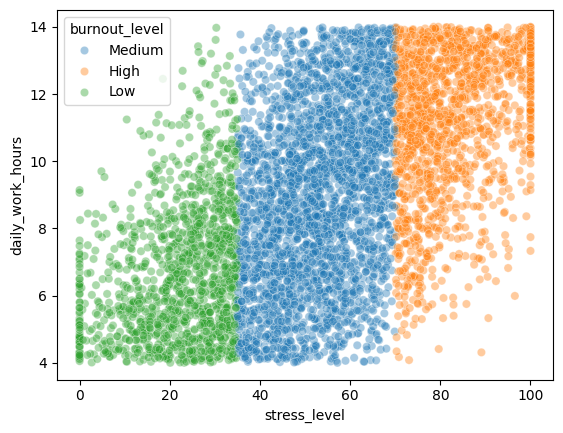

In [124]:
#Seleccionar las dos mejores variables: stress_level y daily_work_hours
vars_knn = ["stress_level", "daily_work_hours"]

X_train_knn = X_train_sc[vars_knn]
X_test_knn = X_test_sc[vars_knn]

#Diagrama de dispersión con las dos variables seleccionadas
plt.figure()
sns.scatterplot(data=datos, x="stress_level", y="daily_work_hours",
                hue="burnout_level", alpha=0.4)
plt.show()

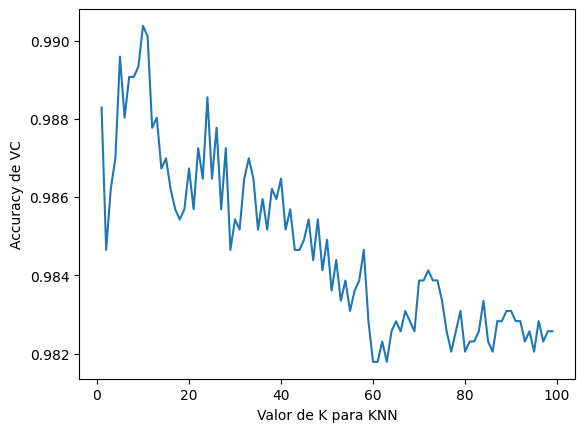

El valor de K que maximiza la accuracy es 10


In [125]:
#Validación cruzada para encontrar el mejor valor de k
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

k_range = range(1, 100)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_knn, y_train, cv=10, scoring="accuracy")
    k_scores.append(scores.mean())

#Graficar accuracy vs k
plt.plot(k_range, k_scores)
plt.xlabel("Valor de K para KNN")
plt.ylabel("Accuracy de VC")
plt.show()

print("El valor de K que maximiza la accuracy es", np.argmax(k_scores) + 1)

In [126]:
#Ajustar el modelo KNN con el mejor k=10
from sklearn.neighbors import KNeighborsClassifier

model_KNN_10 = KNeighborsClassifier(n_neighbors=10)
model_KNN_10.fit(X_train_knn, y_train)

KNeighborsClassifier(n_neighbors=10)

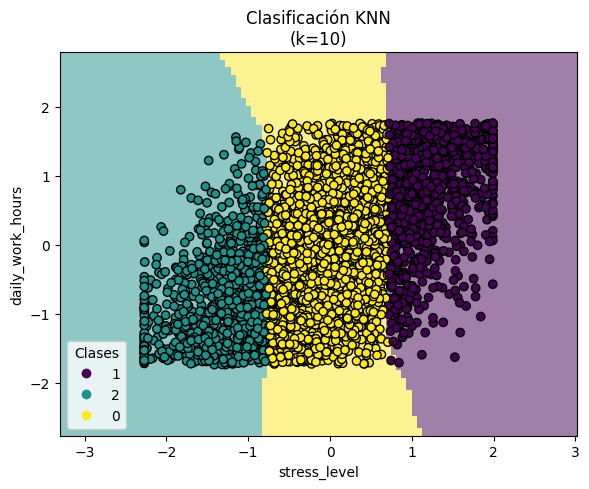

In [127]:
#Visualizar la frontera de decisión
from sklearn.inspection import DecisionBoundaryDisplay

fig, ax = plt.subplots(figsize=(6, 5))
weights = "uniform"
model_KNN_10.set_params(weights=weights).fit(X_train_knn, y_train)

disp = DecisionBoundaryDisplay.from_estimator(
    model_KNN_10,
    X_train_knn,
    response_method="predict",
    plot_method="pcolormesh",
    xlabel="stress_level",
    ylabel="daily_work_hours",
    shading="auto",
    alpha=0.5,
    ax=ax,
)

scatter = disp.ax_.scatter(
    X_train_knn.iloc[:, 0],
    X_train_knn.iloc[:, 1],
    c=y_train, edgecolors="k"
)

disp.ax_.legend(
    scatter.legend_elements()[0],
    y_train.unique(),
    loc="lower left",
    title="Clases",
)

disp.ax_.set_title(f"Clasificación KNN\n(k={model_KNN_10.n_neighbors})")
plt.tight_layout()
plt.show()

In [128]:
#Obtener el accuracy_score
from sklearn.metrics import accuracy_score

y_pred_knn = model_KNN_10.predict(X_test_knn)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("El accuracy score que se tiene es %s" %accuracy_knn)

El accuracy score que se tiene es 0.9872495446265938


Text(50.722222222222214, 0.5, 'Real')

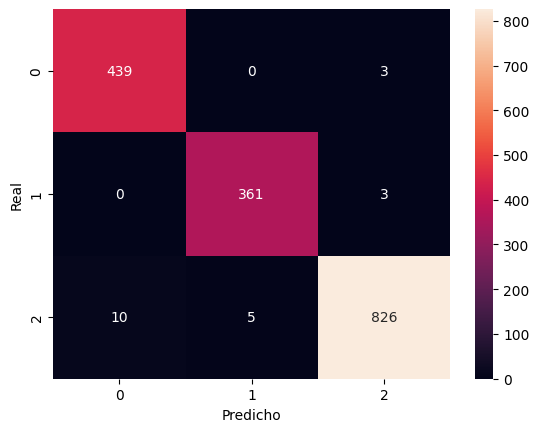

In [129]:
#Obtener la matriz de confusión
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [130]:
#Obtener la precisión, recall y F1
from sklearn.metrics import precision_score, recall_score, f1_score

precision_knn = precision_score(y_test, y_pred_knn, average="macro")
recall_knn = recall_score(y_test, y_pred_knn, average="macro")
f1_knn = f1_score(y_test, y_pred_knn, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"],
                          "Valores": [precision_knn, recall_knn, f1_knn]})
metricas

,Métricas,Valores
0,Precisión,0.985619
1,Recall,0.989045
2,F1,0.987299


In [131]:
#Predicción con la media de las variables escaladas
media_knn = np.mean(X_train_knn, axis=0)
prediccion = model_KNN_10.predict(media_knn.values.reshape(1, -1))
print("La predicción que se tiene para la media de las variables es %s" %le.inverse_transform(prediccion))

La predicción que se tiene para la media de las variables es ['Medium']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names


In [132]:
proba = model_KNN_10.predict_proba(media_knn.values.reshape(1, -1))
print("La probabilidad de pertenecer a High es %s" %proba[0, 0])
print("La probabilidad de pertenecer a Low es %s" %proba[0, 1])
print("La probabilidad de pertenecer a Medium es %s" %proba[0, 2])

La probabilidad de pertenecer a High es 0.0
La probabilidad de pertenecer a Low es 0.0
La probabilidad de pertenecer a Medium es 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names


## Parte e) - Árboles de decisión

In [133]:
#Árbol de decisión con profundidad máxima de 3
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(max_depth=3, random_state=20230196)
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=20230196)

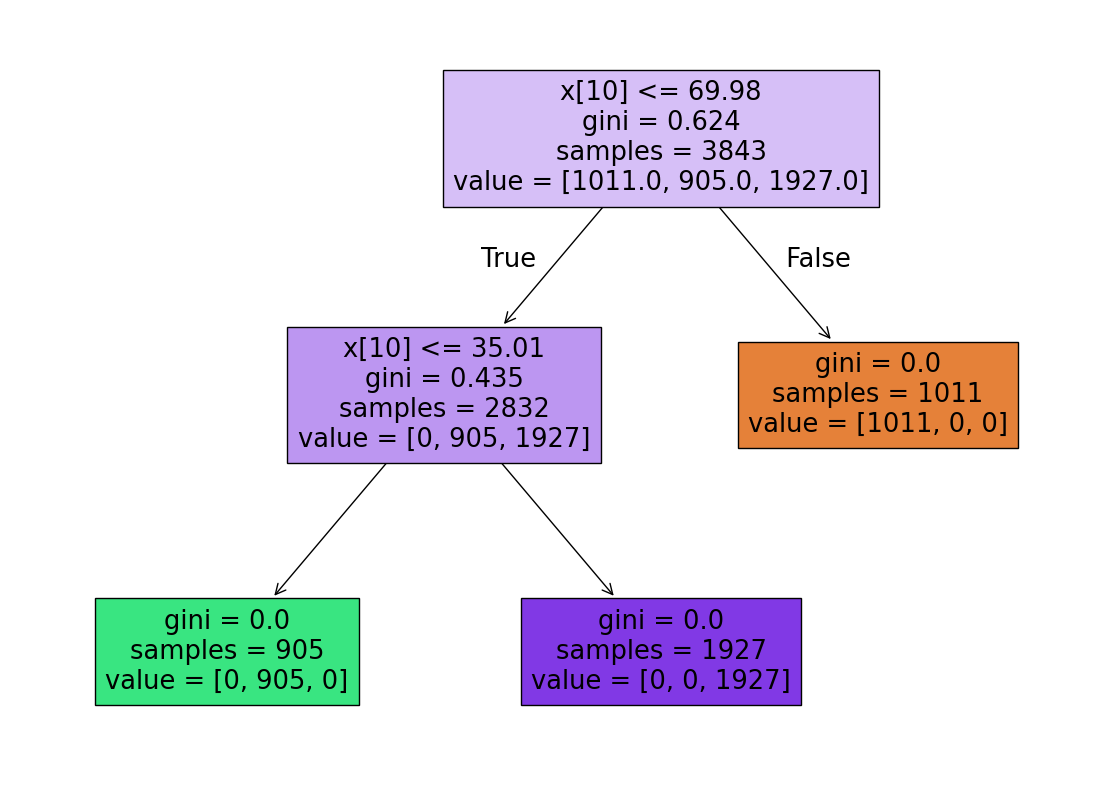

In [134]:
#Visualizar el árbol
from sklearn import tree
plt.figure(figsize=(14, 10))
tree.plot_tree(tree_clf, filled=True)
plt.show()

In [135]:
#Obtener el accuracy_score
from sklearn.metrics import accuracy_score

y_pred_a = tree_clf.predict(X_test)
accuracy_a = accuracy_score(y_test, y_pred_a)
print("El accuracy score que se tiene es %s" %accuracy_a)

El accuracy score que se tiene es 1.0


Text(50.722222222222214, 0.5, 'Real')

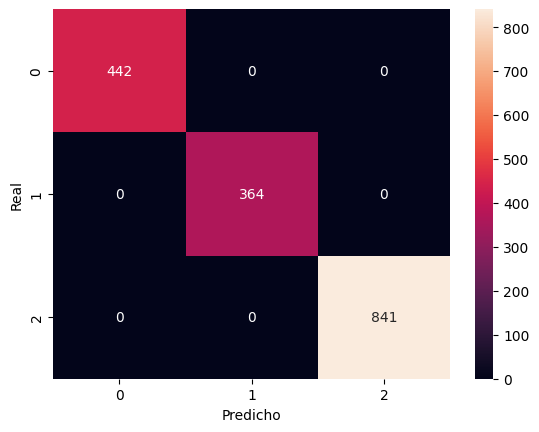

In [136]:
#Obtener la matriz de confusión
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_a)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [137]:
#Obtener la precisión, recall y F1
from sklearn.metrics import precision_score, recall_score, f1_score

precision_a = precision_score(y_test, y_pred_a, average="macro")
recall_a = recall_score(y_test, y_pred_a, average="macro")
f1_a = f1_score(y_test, y_pred_a, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"],
                          "Valores": [precision_a, recall_a, f1_a]})
metricas

,Métricas,Valores
0,Precisión,1.0
1,Recall,1.0
2,F1,1.0


In [138]:
#Árbol de decisión con mínimo 40 observaciones por nodo hoja
from sklearn.tree import DecisionTreeClassifier

tree_clf_b = DecisionTreeClassifier(min_samples_leaf=40, random_state=20230196)
tree_clf_b.fit(X_train, y_train)

DecisionTreeClassifier(min_samples_leaf=40, random_state=20230196)

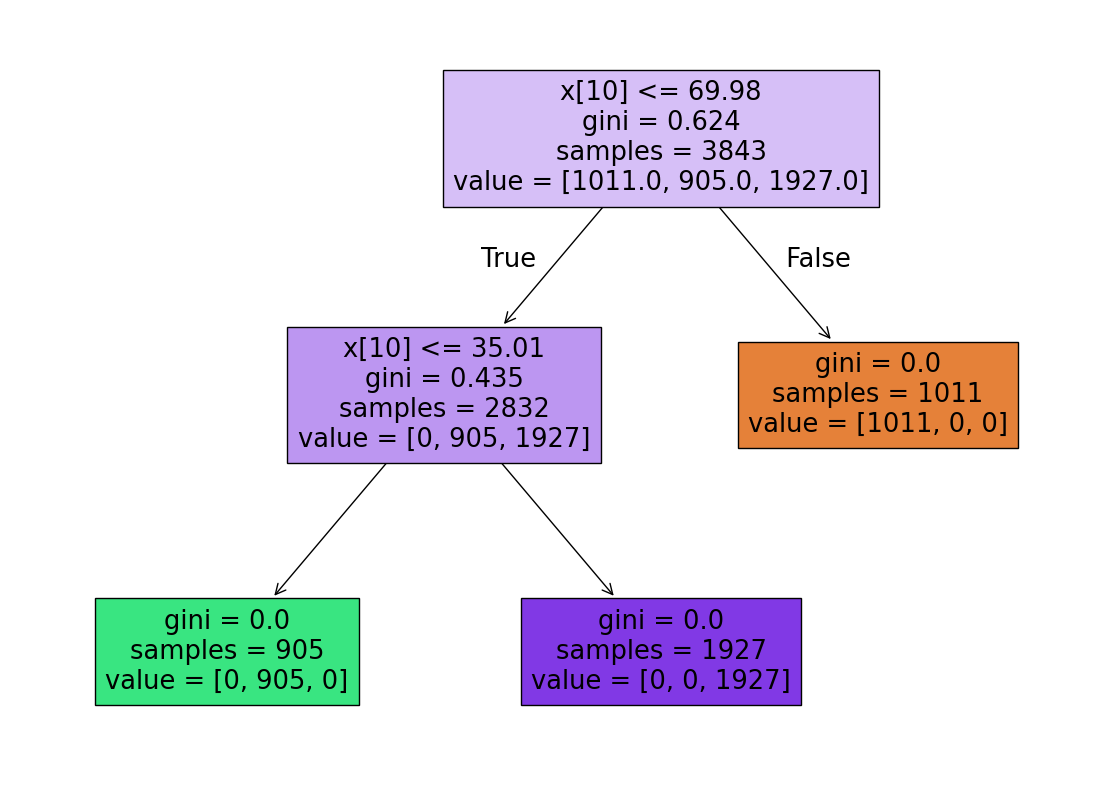

In [139]:
#Visualizar el árbol
from sklearn import tree
plt.figure(figsize=(14, 10))
tree.plot_tree(tree_clf_b, filled=True)
plt.show()

In [140]:
#Obtener el accuracy_score
from sklearn.metrics import accuracy_score

y_pred_b = tree_clf_b.predict(X_test)
accuracy_b = accuracy_score(y_test, y_pred_b)
print("El accuracy score que se tiene es %s" %accuracy_b)

El accuracy score que se tiene es 1.0


Text(50.722222222222214, 0.5, 'Real')

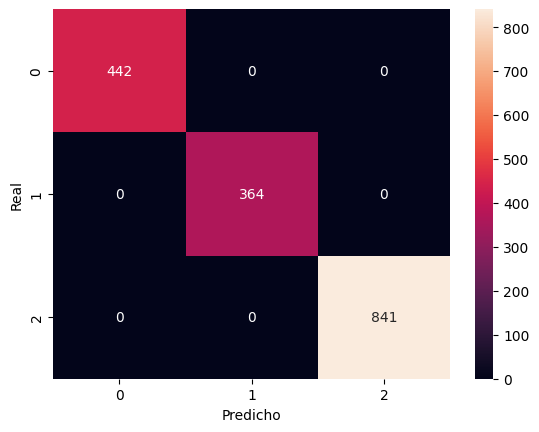

In [141]:
#Obtener la matriz de confusión
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_b)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [142]:
#Obtener la precisión, recall y F1
from sklearn.metrics import precision_score, recall_score, f1_score

precision_b = precision_score(y_test, y_pred_b, average="macro")
recall_b = recall_score(y_test, y_pred_b, average="macro")
f1_b = f1_score(y_test, y_pred_b, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"],
                          "Valores": [precision_b, recall_b, f1_b]})
metricas

,Métricas,Valores
0,Precisión,1.0
1,Recall,1.0
2,F1,1.0


In [143]:
#Predicción con la media de las variables del entrenamiento
X_media = np.mean(X_train, axis=0)
prediccion_arbol = tree_clf.predict(X_media.values.reshape(1, -1))
print("la prediccion es %s" %le.inverse_transform(prediccion_arbol))

la prediccion es ['Medium']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


## Parte f) - Métodos de ensamble

In [144]:
#Función para visualizar la frontera de decisión (solo 2 variables)
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, alpha=0.5, contour=True):
    axes = [np.min(X.iloc[:, 0]), np.max(X.iloc[:, 0]),
            np.min(X.iloc[:, 1]), np.max(X.iloc[:, 1])]
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    custom_cmap = ListedColormap(["#fafab0", "#9898ff", "#a0faa0"])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    if contour:
        custom_cmap2 = ListedColormap(["#7d7d58", "#4c4c7f", "#507d50"])
        plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    plt.plot(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], "yo", alpha=alpha)
    plt.plot(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], "bs", alpha=alpha)
    plt.plot(X.iloc[:, 0][y==2], X.iloc[:, 1][y==2], "g^", alpha=alpha)
    plt.axis(axes)
    plt.xlabel(r"$stress\_level$", fontsize=14)
    plt.ylabel(r"$daily\_work\_hours$", fontsize=14)

In [145]:
#Modelo Bagging (con reemplazamiento)
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=300,
                            max_samples=75, bootstrap=True, random_state=2026)
bag_clf.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=75,
                  n_estimators=300, random_state=2026)

In [146]:
#Obtener el accuracy_score
from sklearn.metrics import accuracy_score

y_pred_bag = bag_clf.predict(X_test)
accuracy_bag = accuracy_score(y_test, y_pred_bag)
print("El accuracy score que se tiene es %s" %accuracy_bag)

El accuracy score que se tiene es 0.9975713418336369


Text(50.722222222222214, 0.5, 'Real')

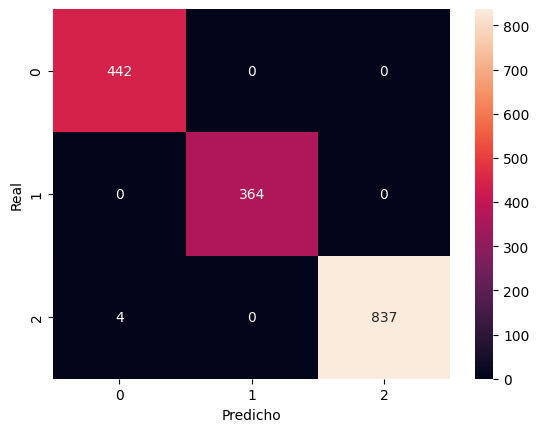

In [147]:
#Obtener la matriz de confusión
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_bag)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [148]:
#Obtener la precisión, recall y F1
from sklearn.metrics import precision_score, recall_score, f1_score

precision_bag = precision_score(y_test, y_pred_bag, average="macro")
recall_bag = recall_score(y_test, y_pred_bag, average="macro")
f1_bag = f1_score(y_test, y_pred_bag, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"],
                          "Valores": [precision_bag, recall_bag, f1_bag]})
metricas

,Métricas,Valores
0,Precisión,0.997010
1,Recall,0.998415
2,F1,0.997704


In [149]:
#Modelo Pasting (sin reemplazamiento)
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

pas_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=300,
                            max_samples=75, bootstrap=False, random_state=20230196)
pas_clf.fit(X_train, y_train)
y_pred_pas = pas_clf.predict(X_test)

In [150]:
#Obtener el accuracy_score
from sklearn.metrics import accuracy_score

y_pred_pas = pas_clf.predict(X_test)
accuracy_pas = accuracy_score(y_test, y_pred_pas)
print("El accuracy score que se tiene es %s" %accuracy_pas)

El accuracy score que se tiene es 0.9987856709168185


Text(50.722222222222214, 0.5, 'Real')

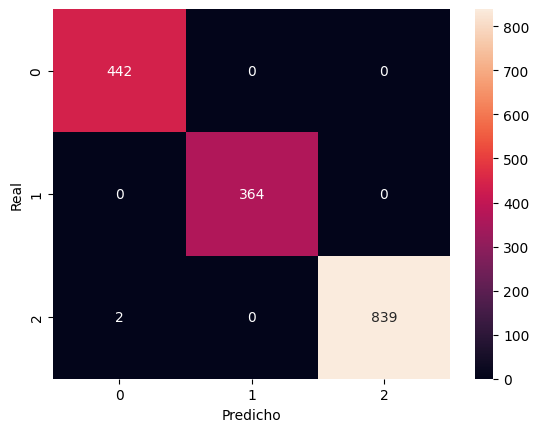

In [151]:
#Obtener la matriz de confusión
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_pas)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [152]:
#Obtener la precisión, recall y F1
from sklearn.metrics import precision_score, recall_score, f1_score

precision_pas = precision_score(y_test, y_pred_pas, average="macro")
recall_pas = recall_score(y_test, y_pred_pas, average="macro")
f1_pas = f1_score(y_test, y_pred_pas, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"],
                          "Valores": [precision_pas, recall_pas, f1_pas]})
metricas

,Métricas,Valores
0,Precisión,0.998498
1,Recall,0.999207
2,F1,0.998851


In [153]:
#Modelo Random Forest (max_leaf_nodes=6)
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=300, max_leaf_nodes=6, random_state=20230196)
rnd_clf.fit(X_train, y_train)

RandomForestClassifier(max_leaf_nodes=6, n_estimators=300,
                       random_state=20230196)

In [154]:
#Obtener el accuracy_score
from sklearn.metrics import accuracy_score

y_pred_rf = rnd_clf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("El accuracy score que se tiene es %s" %accuracy_rf)

El accuracy score que se tiene es 0.9933211900425015


Text(50.722222222222214, 0.5, 'Real')

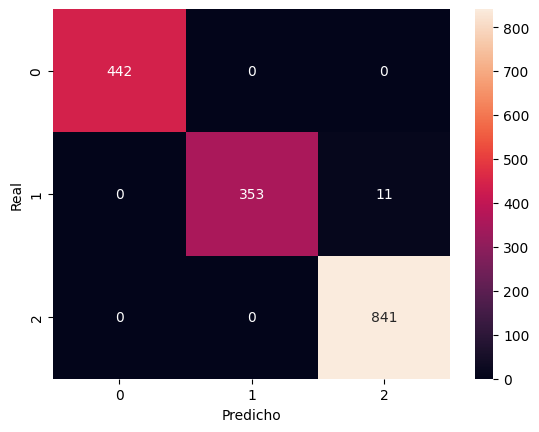

In [155]:
#Obtener la matriz de confusión
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [156]:
#Obtener la precisión, recall y F1
from sklearn.metrics import precision_score, recall_score, f1_score

precision_rf = precision_score(y_test, y_pred_rf, average="macro")
recall_rf = recall_score(y_test, y_pred_rf, average="macro")
f1_rf = f1_score(y_test, y_pred_rf, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"],
                          "Valores": [precision_rf, recall_rf, f1_rf]})
metricas

,Métricas,Valores
0,Precisión,0.995696
1,Recall,0.989927
2,F1,0.992720


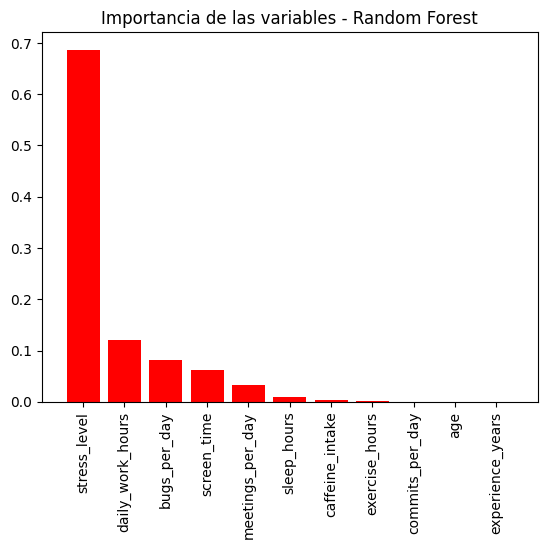

In [157]:
#Importancia de las variables - Random Forest
importancias = rnd_clf.feature_importances_

importancias_clf = pd.DataFrame({"Variable": predictoras.columns,
                                  "Importancias": rnd_clf.feature_importances_})

indices = np.argsort(importancias)[::-1]

plt.title("Importancia de las variables - Random Forest")
plt.bar(range(X_train.shape[1]), importancias[indices], color="r", align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()

In [158]:
importancias_clf

,Variable,Importancias
0,age,0.000034
1,experience_years,0.000000
2,daily_work_hours,0.121446
3,sleep_hours,0.010129
4,caffeine_intake,0.003337
5,bugs_per_day,0.081193
6,commits_per_day,0.000058
7,meetings_per_day,0.033560
8,screen_time,0.062697
9,exercise_hours,0.000805


In [159]:
#Modelo Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(n_estimators=300, random_state=20230196)
gb_clf.fit(X_train, y_train)

GradientBoostingClassifier(n_estimators=300, random_state=20230196)

In [160]:
#Obtener el accuracy_score
from sklearn.metrics import accuracy_score

y_pred_gb = gb_clf.predict(X_test)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print("El accuracy score que se tiene es %s" %accuracy_gb)

El accuracy score que se tiene es 1.0


Text(50.722222222222214, 0.5, 'Real')

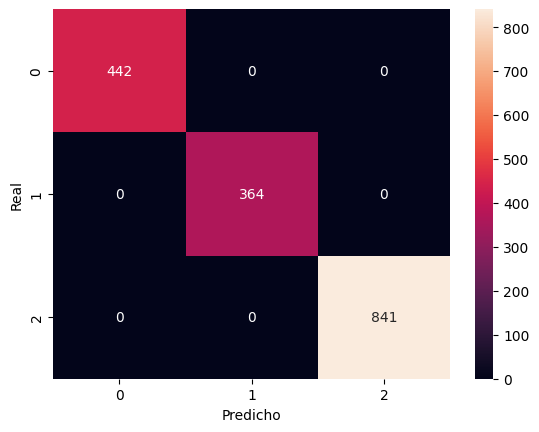

In [161]:
#Obtener la matriz de confusión
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [162]:
#Obtener la precisión, recall y F1
from sklearn.metrics import precision_score, recall_score, f1_score

precision_gb = precision_score(y_test, y_pred_gb, average="macro")
recall_gb = recall_score(y_test, y_pred_gb, average="macro")
f1_gb = f1_score(y_test, y_pred_gb, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"],
                          "Valores": [precision_gb, recall_gb, f1_gb]})
metricas

,Métricas,Valores
0,Precisión,1.0
1,Recall,1.0
2,F1,1.0


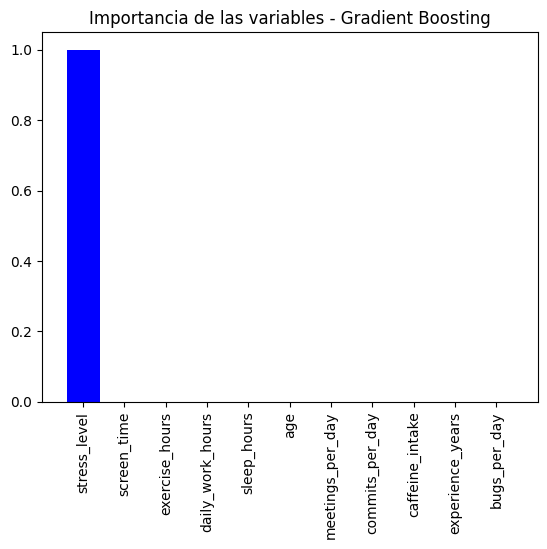

In [163]:
#Importancia de las variables - Gradient Boosting
importancias_gb = gb_clf.feature_importances_

importancias_gb_df = pd.DataFrame({"Variable": predictoras.columns,
                                    "Importancias": importancias_gb})

indices_gb = np.argsort(importancias_gb)[::-1]

plt.title("Importancia de las variables - Gradient Boosting")
plt.bar(range(X_train.shape[1]), importancias_gb[indices_gb], color="b", align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices_gb], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()

In [164]:
importancias_gb_df

,Variable,Importancias
0,age,3.343076e-16
1,experience_years,-6.416771e-19
2,daily_work_hours,3.863862e-15
3,sleep_hours,1.822454e-15
4,caffeine_intake,0.000000e+00
5,bugs_per_day,-3.731599e-18
6,commits_per_day,0.000000e+00
7,meetings_per_day,0.000000e+00
8,screen_time,5.228742e-15
9,exercise_hours,4.125660e-15


In [165]:
#Ajuste de hiperparámetros para Gradient Boosting
learning_rates = [1, 0.5, 0.25, 0.1, 0.05, 0.01]
max_depths = [2, 3, 4, 5]

resultados_test = list()

for eta in learning_rates:
    for d in max_depths:
        gb_clf_i = GradientBoostingClassifier(learning_rate=eta, n_estimators=300,
                                              random_state=20230196, max_depth=d)
        gb_clf_i.fit(X_train, y_train)
        y_pred_test = gb_clf_i.predict(X_test)
        acc_test = accuracy_score(y_test, y_pred_test)
        resultados_test.append(acc_test)

In [166]:
resultados_test

[1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

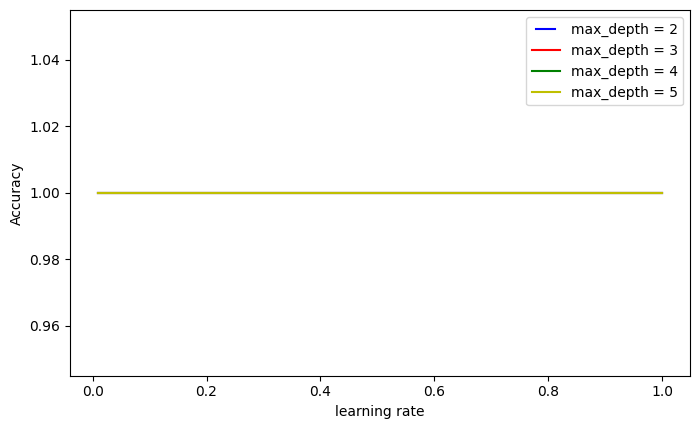

In [167]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerLine2D

plt.figure(figsize=(8, 4.75))
line1, = plt.plot(learning_rates, resultados_test[0:6], "b", label="max_depth = 2")
line2, = plt.plot(learning_rates, resultados_test[6:12], "r", label="max_depth = 3")
line3, = plt.plot(learning_rates, resultados_test[12:18], "g", label="max_depth = 4")
line4, = plt.plot(learning_rates, resultados_test[18:24], "y", label="max_depth = 5")
plt.legend(handler_map={line1: HandlerLine2D(numpoints=4)})
plt.ylabel("Accuracy")
plt.xlabel("learning rate")
plt.show()

In [168]:
#Gradient Boosting ajustado con los mejores parámetros (lr=1, max_depth=2)
from sklearn.ensemble import GradientBoostingClassifier

gb_clf_b = GradientBoostingClassifier(n_estimators=300, random_state=20230196,
                                       max_depth=2, learning_rate=1)
gb_clf_b.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=1, max_depth=2, n_estimators=300,
                           random_state=20230196)

In [169]:
#Obtener el accuracy_score
from sklearn.metrics import accuracy_score

y_pred_gb_b = gb_clf_b.predict(X_test)
accuracy_gb_b = accuracy_score(y_test, y_pred_gb_b)
print("El accuracy score que se tiene es %s" %accuracy_gb_b)

El accuracy score que se tiene es 1.0


Text(50.722222222222214, 0.5, 'Real')

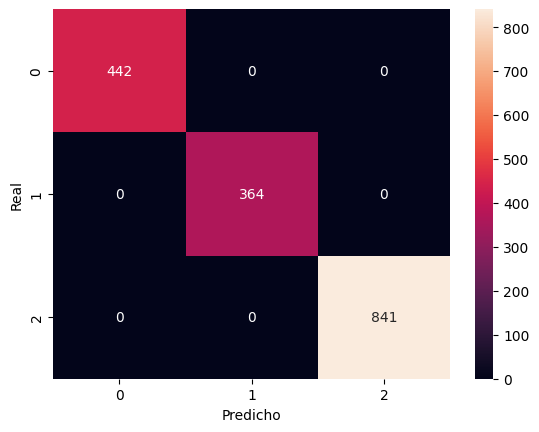

In [170]:
#Obtener la matriz de confusión
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_gb_b)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [171]:
#Obtener la precisión, recall y F1
from sklearn.metrics import precision_score, recall_score, f1_score

precision_gb_b = precision_score(y_test, y_pred_gb_b, average="macro")
recall_gb_b = recall_score(y_test, y_pred_gb_b, average="macro")
f1_gb_b = f1_score(y_test, y_pred_gb_b, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"],
                          "Valores": [precision_gb_b, recall_gb_b, f1_gb_b]})
metricas

,Métricas,Valores
0,Precisión,1.0
1,Recall,1.0
2,F1,1.0


In [172]:
#Comparativa general de todos los modelos
modelos = ["Regresión Logística", "KNN (k=10)", "Árbol max_depth=3",
           "Árbol min_samples_leaf=40", "Bagging", "Pasting",
           "Random Forest", "Gradient Boosting", "Gradient Boosting ajustado"]

accuracy_scores = [accuracy_lr, accuracy_knn, accuracy_a, accuracy_b,
                   accuracy_bag, accuracy_pas, accuracy_rf, accuracy_gb, accuracy_gb_b]
precision_scores = [precision_lr, precision_knn, precision_a, precision_b,
                    precision_bag, precision_pas, precision_rf, precision_gb, precision_gb_b]
recall_scores = [recall_lr, recall_knn, recall_a, recall_b,
                 recall_bag, recall_pas, recall_rf, recall_gb, recall_gb_b]
f1_scores = [f1_lr, f1_knn, f1_a, f1_b,
             f1_bag, f1_pas, f1_rf, f1_gb, f1_gb_b]

resultados = pd.DataFrame({"Modelos": modelos, "Accuracy": accuracy_scores,
                            "Precisión": precision_scores, "Recall": recall_scores,
                            "F1 Score": f1_scores})
resultados["Media"] = np.mean(resultados.drop("Modelos", axis=1), axis=1)
resultados

,Modelos,Accuracy,Precisión,Recall,F1 Score,Media
0,Regresión Logística,0.984214,0.984761,0.983070,0.983885,0.983982
1,KNN (k=10),0.987250,0.985619,0.989045,0.987299,0.987303
2,Árbol max_depth=3,1.000000,1.000000,1.000000,1.000000,1.000000
3,Árbol min_samples_leaf=40,1.000000,1.000000,1.000000,1.000000,1.000000
4,Bagging,0.997571,0.997010,0.998415,0.997704,0.997675
5,Pasting,0.998786,0.998498,0.999207,0.998851,0.998836
6,Random Forest,0.993321,0.995696,0.989927,0.992720,0.992916
7,Gradient Boosting,1.000000,1.000000,1.000000,1.000000,1.000000
8,Gradient Boosting ajustado,1.000000,1.000000,1.000000,1.000000,1.000000


In [173]:
#Modelo con mayor media de métricas
mejor_modelo = resultados.loc[resultados["Media"].idxmax(), "Modelos"]
mejor_media = resultados["Media"].max()
print("El modelo con mayor media es: %s" %mejor_modelo)
print("La media de métricas es: %s" %mejor_media)

El modelo con mayor media es: Árbol max_depth=3
La media de métricas es: 1.0


A partir de la tabla comparativa final se observa que los modelos Árbol de decisión con max_depth=3, Árbol de decisión con min_samples_leaf=40, Gradient Boosting y Gradient Boosting ajustado obtuvieron el mejor desempeño con accuracy, precisión, recall y F1-score de 1.0, clasificando perfectamente el nivel de burnout en el conjunto de validación. Los modelos Pasting con media=0.9983 y Bagging con media=0.9977 presentaron resultados muy Buenos. El Random Forest con media=0.9974, el KNN con k=10 con media=0.9873 y la Regresión Logística con media=0.9840 también mostraron un rendimiento excelente. En general todos los modelos evaluados son adecuados para clasificar el nivel de agotamiento laboral. Sin embargo, considerando la simplicidad e interpretabilidad, el árbol de decisión con max_depth=3 es el modelo más recomendado al lograr clasificación perfecta con la menor complejidad, lo cual es posible gracias a que la variable stress_level actúa como separador casi perfecto entre las tres clases de burnout.